<a href="https://colab.research.google.com/github/Tanay2109/Hull-White-2F-G2-for-Multi-Factor-Interest-Rate-Modelling-Derivatives-Pricing/blob/main/HW_2F_for_IR_modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import libraries for numerical computation, optimization, and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, brentq
from scipy.stats import norm
from scipy.interpolate import CubicSpline
np.random.seed(42)

In [2]:
# Generate synthetic historical SOFR OIS par curves (2018-2023) and select the latest curve for calibration
tenors = np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30])
dates = ['2018-12-31', '2019-12-31', '2020-12-31', '2021-12-31', '2022-12-31', '2023-12-31']
curve_shapes = [
    [2.45,2.50,2.55,2.60,2.55,2.45,2.35,2.30,2.28,2.25,2.20],
    [1.60,1.58,1.55,1.52,1.50,1.48,1.47,1.48,1.50,1.52,1.55],
    [0.10,0.10,0.12,0.18,0.28,0.55,0.80,1.00,1.15,1.25,1.30],
    [0.20,0.30,0.55,0.90,1.10,1.30,1.45,1.55,1.65,1.70,1.75],
    [4.55,4.75,4.80,4.55,4.30,4.10,4.00,3.95,3.95,4.00,4.05],
    [5.35,5.30,5.00,4.55,4.20,4.00,3.95,4.00,4.05,4.10,4.15]
]
ois_history = pd.DataFrame(curve_shapes, index=pd.to_datetime(dates), columns=tenors)
market_rates = ois_history.iloc[-1].values / 100

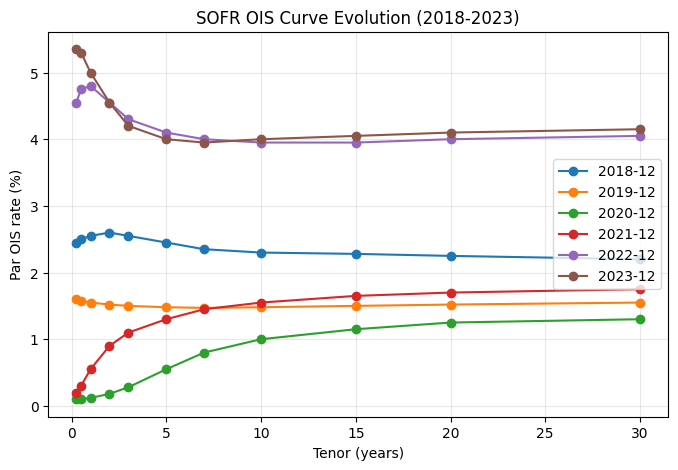

In [3]:
# Visualize evolution of the SOFR OIS curve from 2018 to 2023
plt.figure(figsize=(8,5))
for d in ois_history.index:
    plt.plot(tenors, ois_history.loc[d], marker='o', label=d.strftime('%Y-%m'))
plt.xlabel('Tenor (years)')
plt.ylabel('Par OIS rate (%)')
plt.title('SOFR OIS Curve Evolution (2018-2023)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [4]:
# Build the continuously-compounded zero curve and discount factor curve from market OIS rates
zero_rates = market_rates
disc_factors = np.exp(-zero_rates * tenors)
curve_df = pd.DataFrame({'tenor': tenors, 'zero_rate': zero_rates, 'discount_factor': disc_factors})
curve_df

,tenor,zero_rate,discount_factor
0,0.25,0.0535,0.986714
1,0.50,0.0530,0.973848
2,1.00,0.0500,0.951229
3,2.00,0.0455,0.913018
4,3.00,0.0420,0.881615
5,5.00,0.0400,0.818731
6,7.00,0.0395,0.758434
7,10.00,0.0400,0.670320
8,15.00,0.0405,0.544711
9,20.00,0.0410,0.440432


In [5]:
# Create interpolated market discount curve P(0,t) and instantaneous forward curve f(0,t)
log_df_spline = CubicSpline(tenors, np.log(disc_factors))

def P_market(t):
    t = np.maximum(t, 1e-6)
    return np.exp(log_df_spline(t))

def f_market(t):
    t = np.maximum(t, 1e-6)
    return -log_df_spline(t, 1)

In [6]:
# Generate synthetic SOFR swaption normal volatility surface and compute market prices via the Bachelier model
expiries = np.array([1, 2, 5])
swap_tenors = np.array([2, 5, 10])
normal_vols_bps = np.array([
    [95, 105, 100],
    [100, 110, 105],
    [90, 100, 98]
])

def par_swap_rate(T_expiry, T_tenor):
    pay_times = T_expiry + np.arange(1, T_tenor+1)
    annuity = np.sum(P_market(pay_times))
    return (P_market(T_expiry) - P_market(pay_times[-1])) / annuity

def bachelier_payer_price(F, K, vol, T_expiry, annuity):
    if vol <= 0 or T_expiry <= 0:
        return annuity * max(F-K, 0)
    d = (F-K)/(vol*np.sqrt(T_expiry))
    return annuity * ((F-K)*norm.cdf(d) + vol*np.sqrt(T_expiry)*norm.pdf(d))

market_data = []
for i, Te in enumerate(expiries):
    for j, Tt in enumerate(swap_tenors):
        pay_times = Te + np.arange(1, Tt+1)
        annuity = np.sum(P_market(pay_times))
        F = par_swap_rate(Te, Tt)
        vol = normal_vols_bps[i,j]/10000
        price = bachelier_payer_price(F, F, vol, Te, annuity)
        market_data.append({'expiry':Te,'tenor':Tt,'strike':F,'par_rate':F,
                             'vol':vol,'annuity':annuity,'price':price,'pay_times':pay_times})

In [7]:
# Define the G2++ zero-coupon bond pricing formula P(t,T,x,y), fitted exactly to the market curve
def B_func(z, tau):
    return (1-np.exp(-z*tau))/z

def V_func(tau, a, b, sigma, eta, rho):
    term1 = (sigma**2/a**2)*(tau + (2/a)*np.exp(-a*tau) - (1/(2*a))*np.exp(-2*a*tau) - 3/(2*a))
    term2 = (eta**2/b**2)*(tau + (2/b)*np.exp(-b*tau) - (1/(2*b))*np.exp(-2*b*tau) - 3/(2*b))
    term3 = (2*rho*sigma*eta/(a*b))*(tau + (np.exp(-a*tau)-1)/a + (np.exp(-b*tau)-1)/b - (np.exp(-(a+b)*tau)-1)/(a+b))
    return term1+term2+term3

def bond_price(t, T, x, y, params):
    a,b,sigma,eta,rho = params
    A = (P_market(T)/P_market(t)) * np.exp(0.5*(V_func(T-t,a,b,sigma,eta,rho) - V_func(T,a,b,sigma,eta,rho) + V_func(t,a,b,sigma,eta,rho)))
    return A*np.exp(-B_func(a,T-t)*x - B_func(b,T-t)*y)

def phi_func(t, params):
    a,b,sigma,eta,rho = params
    return f_market(t) + (sigma**2/(2*a**2))*(1-np.exp(-a*t))**2 + (eta**2/(2*b**2))*(1-np.exp(-b*t))**2 + (rho*sigma*eta/(a*b))*(1-np.exp(-a*t))*(1-np.exp(-b*t))

In [8]:
# Simulate correlated G2++ factor paths x(t), y(t) and the short rate r(t) via exact OU discretization with antithetic variates
def simulate_paths(params, n_paths, horizon, dt, seed=0):
    a,b,sigma,eta,rho = params
    n_steps = int(horizon/dt)
    rng = np.random.default_rng(seed)
    half = n_paths//2
    z1 = rng.standard_normal((half, n_steps))
    z2 = rng.standard_normal((half, n_steps))
    z1 = np.vstack([z1,-z1]); z2 = np.vstack([z2,-z2])
    w2 = rho*z1 + np.sqrt(1-rho**2)*z2
    x = np.zeros((z1.shape[0], n_steps+1))
    y = np.zeros((z1.shape[0], n_steps+1))
    ea = np.exp(-a*dt); eb = np.exp(-b*dt)
    sx = sigma*np.sqrt((1-ea**2)/(2*a))
    sy = eta*np.sqrt((1-eb**2)/(2*b))
    for k in range(n_steps):
        x[:,k+1] = x[:,k]*ea + sx*z1[:,k]
        y[:,k+1] = y[:,k]*eb + sy*w2[:,k]
    t_grid = np.linspace(0, horizon, n_steps+1)
    r = x + y + phi_func(t_grid, params)
    return t_grid, x, y, r

In [9]:
# Price a European payer swaption via Monte Carlo using simulated factor paths and the analytic bond-price formula at exercise
def mc_swaption_price(params, expiry, pay_times, strike, n_paths=3000, dt=0.1, seed=1):
    t_grid, x, y, r = simulate_paths(params, n_paths, expiry, dt, seed)
    bank_account = np.exp(np.trapz(r, t_grid, axis=1))
    x_T, y_T = x[:,-1], y[:,-1]
    bonds = np.array([bond_price(expiry, T, x_T, y_T, params) for T in pay_times])
    coupon_bond = strike*np.sum(bonds[:-1], axis=0) + (1+strike)*bonds[-1]
    payoff = np.maximum(1-coupon_bond, 0)
    return np.mean(payoff/bank_account)

In [10]:
# Invert the Bachelier formula to obtain implied normal volatility (in bps) from a swaption price
def implied_normal_vol(price, F, K, T_expiry, annuity):
    def obj(vol):
        return bachelier_payer_price(F, K, vol, T_expiry, annuity) - price
    try:
        return brentq(obj, 1e-6, 0.05, xtol=1e-8)*10000
    except ValueError:
        return np.nan

In [11]:
# Calibrate G2++ parameters (a, b, sigma, eta, rho) to market swaption vols by minimizing RMSE via Monte Carlo pricing
def calibration_objective(theta):
    params = tuple(theta)
    errors = []
    for row in market_data:
        model_price = mc_swaption_price(params, row['expiry'], row['pay_times'], row['strike'], n_paths=2000, dt=0.1, seed=7)
        model_vol = implied_normal_vol(model_price, row['par_rate'], row['strike'], row['expiry'], row['annuity'])
        errors.append(model_vol - row['vol']*10000)
    return np.sqrt(np.nanmean(np.array(errors)**2))

x0 = [0.05, 0.5, 0.01, 0.01, -0.7]
bounds = [(0.001,2),(0.001,2),(0.0001,0.05),(0.0001,0.05),(-0.999,0.999)]
result = minimize(calibration_objective, x0, method='Nelder-Mead', bounds=bounds,
                   options={'xatol':1e-4,'fatol':1e-4,'maxiter':100})
calibrated_params = tuple(result.x)
calibration_rmse = result.fun
print(f"Calibrated params (a,b,sigma,eta,rho): {calibrated_params}")
print(f"Calibration RMSE: {calibration_rmse:.2f} bps")

/tmp/ipykernel_454/747187564.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  bank_account = np.exp(np.trapz(r, t_grid, axis=1))


Calibrated params (a,b,sigma,eta,rho): (np.float64(0.04168084955696477), np.float64(0.2672903940418164), np.float64(0.014473771201880387), np.float64(0.008652261559710727), np.float64(-0.8282222841020961))
Calibration RMSE: 6.24 bps


/tmp/ipykernel_454/747187564.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  bank_account = np.exp(np.trapz(r, t_grid, axis=1))


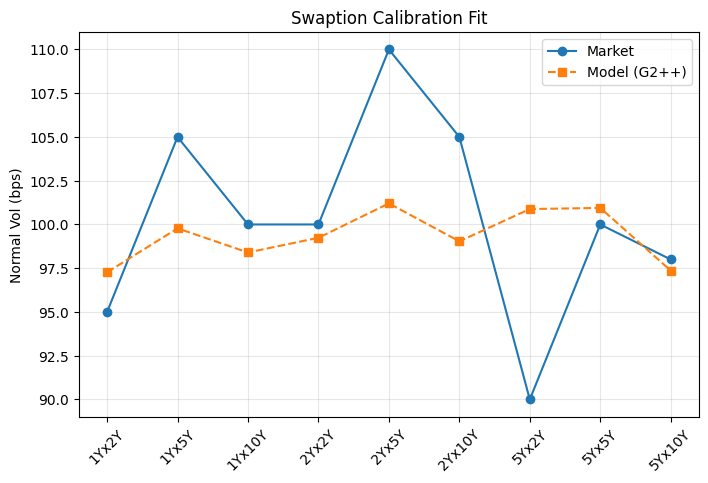

In [12]:
# Compare calibrated model swaption vols against market vols
model_vols = []
for row in market_data:
    model_price = mc_swaption_price(calibrated_params, row['expiry'], row['pay_times'], row['strike'], n_paths=8000, dt=0.05, seed=99)
    model_vols.append(implied_normal_vol(model_price, row['par_rate'], row['strike'], row['expiry'], row['annuity']))

labels = [f"{int(r['expiry'])}Yx{int(r['tenor'])}Y" for r in market_data]
market_vols_bps = [r['vol']*10000 for r in market_data]

plt.figure(figsize=(8,5))
plt.plot(labels, market_vols_bps, 'o-', label='Market')
plt.plot(labels, model_vols, 's--', label='Model (G2++)')
plt.ylabel('Normal Vol (bps)')
plt.title('Swaption Calibration Fit')
plt.legend(); plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.show()

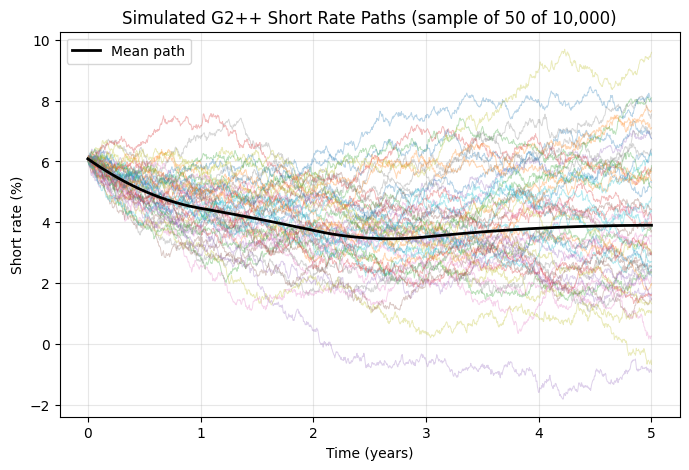

In [13]:
# Simulate 10,000 short-rate paths over a 5-year horizon using the calibrated G2++ model
t_grid, x_sim, y_sim, r_sim = simulate_paths(calibrated_params, n_paths=10000, horizon=5, dt=1/252, seed=123)

plt.figure(figsize=(8,5))
for i in range(50):
    plt.plot(t_grid, r_sim[i]*100, alpha=0.3, linewidth=0.7)
plt.plot(t_grid, np.mean(r_sim,axis=0)*100, color='black', linewidth=2, label='Mean path')
plt.xlabel('Time (years)'); plt.ylabel('Short rate (%)')
plt.title('Simulated G2++ Short Rate Paths (sample of 50 of 10,000)')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [14]:
# Price a 2Y-into-5Y payer swaption using the full 10,000-path Monte Carlo simulation and benchmark against the market price
test_swaption = market_data[4]
mc_price = mc_swaption_price(calibrated_params, test_swaption['expiry'], test_swaption['pay_times'],
                              test_swaption['strike'], n_paths=10000, dt=0.02, seed=321)
market_price = test_swaption['price']
pricing_error_bps = abs(mc_price - market_price)/test_swaption['annuity']*10000
print(f"MC price: {mc_price:.6f}, Market price: {market_price:.6f}")
print(f"Pricing error: {pricing_error_bps:.2f} bps")

MC price: 0.023207, Market price: 0.025428
Pricing error: 5.42 bps


/tmp/ipykernel_454/747187564.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  bank_account = np.exp(np.trapz(r, t_grid, axis=1))


In [15]:
# Simulate 10-day-ahead scenarios and compute the P&L distribution for a 10-year zero-coupon bond position
horizon_days = 10/252
t10, x10, y10, r10 = simulate_paths(calibrated_params, n_paths=10000, horizon=horizon_days, dt=horizon_days/10, seed=555)
x_10d, y_10d = x10[:,-1], y10[:,-1]
notional = 100
V0 = notional*bond_price(0, 10, 0, 0, calibrated_params)
V10 = notional*bond_price(horizon_days, 10, x_10d, y_10d, calibrated_params)
pnl = V10 - V0
VaR_99 = -np.percentile(pnl, 1)
print(f"10-day 99% VaR: {VaR_99:.4f} (per 100 notional)")

10-day 99% VaR: 2.6971 (per 100 notional)


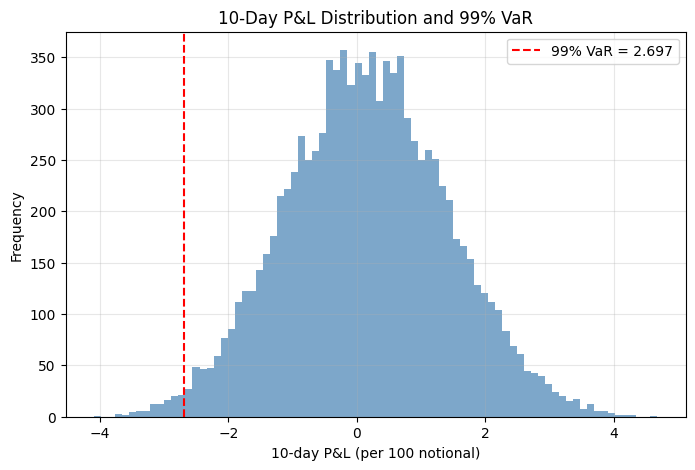

In [16]:
# Visualize the simulated 10-day P&L distribution and the 99% VaR threshold
plt.figure(figsize=(8,5))
plt.hist(pnl, bins=80, color='steelblue', alpha=0.7)
plt.axvline(-VaR_99, color='red', linestyle='--', label=f'99% VaR = {VaR_99:.3f}')
plt.xlabel('10-day P&L (per 100 notional)'); plt.ylabel('Frequency')
plt.title('10-Day P&L Distribution and 99% VaR')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [17]:
# Backtest the VaR estimate by splitting simulated scenarios into estimation and validation sets
np.random.seed(1)
perm = np.random.permutation(len(pnl))
est_idx, val_idx = perm[:5000], perm[5000:]
VaR_est = -np.percentile(pnl[est_idx], 1)
exceptions = np.sum(pnl[val_idx] < -VaR_est)
coverage = 1 - exceptions/len(val_idx)
print(f"Empirical coverage: {coverage*100:.1f}% (target 99%)")
print(f"Number of exceptions: {exceptions} out of {len(val_idx)}")

Empirical coverage: 98.9% (target 99%)
Number of exceptions: 56 out of 5000


In [18]:
# Print final summary of calibration and risk metrics
print("=== Hull-White 2-Factor (G2++) Model Summary ===")
print(f"Calibrated parameters: a={calibrated_params[0]:.4f}, b={calibrated_params[1]:.4f}, "
      f"sigma={calibrated_params[2]:.4f}, eta={calibrated_params[3]:.4f}, rho={calibrated_params[4]:.4f}")
print(f"Swaption calibration RMSE: {calibration_rmse:.2f} bps")
print(f"Swaption pricing error (out-of-sample): {pricing_error_bps:.2f} bps")
print(f"10-day 99% VaR (per 100 notional): {VaR_99:.4f}")
print(f"Empirical coverage of 99% VaR: {coverage*100:.1f}%")

=== Hull-White 2-Factor (G2++) Model Summary ===
Calibrated parameters: a=0.0417, b=0.2673, sigma=0.0145, eta=0.0087, rho=-0.8282
Swaption calibration RMSE: 6.24 bps
Swaption pricing error (out-of-sample): 5.42 bps
10-day 99% VaR (per 100 notional): 2.6971
Empirical coverage of 99% VaR: 98.9%
